# Part 6 — SHAP Explainability

## Why SHAP and why MACCS keys?

SHAP (SHapley Additive exPlanations) assigns each feature a contribution
value for every individual prediction .

We switch from ECFP6 to **MACCS keys** for this notebook because:
- MACCS keys are directly interpretable 
- Every MACCS bit has a defined SMARTS pattern in the RDKit source

## EGFR pharmacophore context
EGFR inhibitors bind in the ATP-binding pocket via:
1. **H-bond to hinge region** (Met793) — requires H-bond donor/acceptor
2. **π-stacking** with hydrophobic residues (Leu718, Leu792, Leu844) — aromatic rings
3. **Covalent bond to Cys797** (2nd/3rd gen) — requires electrophilic warhead (acrylamide)
4. **Hydrophobic back pocket** — requires lipophilic groups

*Sources: Amelia et al., Molecules 2022 (DOI: 10.3390/molecules27030819);
Zhao et al., J Hematol Oncol 2022 (DOI: 10.1186/s13045-022-01311-6)*

---
## 0. Installs & Imports

In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

import shap
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from rdkit import Chem
from rdkit.Chem import Draw, MACCSkeys, AllChem
from rdkit.Chem.Draw import rdMolDraw2D, SimilarityMaps
from IPython.display import display, Image
import io

print('All imports OK')

All imports OK


---
## 1. Load Model and MACCS Features

In [2]:
# ── Load best model from Part 5 ───────────────────────────────────────────────
with open('../models//best_model_part5.pkl', 'rb') as f:
    model = pickle.load(f)

model_name = type(model).__name__
print(f'Loaded model: {model_name}')

# ── MACCS feature matrix ──────────────────────────────────────────────────────
X_maccs_df  = pd.read_csv('../data/processed/X_maccs.csv')
mol_ids     = X_maccs_df['molecule_chembl_id'].reset_index(drop=True)
X_maccs     = X_maccs_df.drop(columns='molecule_chembl_id').values.astype(np.float32)
maccs_cols  = X_maccs_df.drop(columns='molecule_chembl_id').columns.tolist()

# ── Target ────────────────────────────────────────────────────────────────────
y_pchembl_df = pd.read_csv('../data/processed/y_pchembl.csv').set_index('molecule_chembl_id')
y_reg        = y_pchembl_df.loc[mol_ids, 'pchembl_value'].values

# ── Molecule data for drawing ─────────────────────────────────────────────────
df_clean = pd.read_csv('../data/processed/egfr_bioactivity_cleaned.csv').set_index('molecule_chembl_id')

print(f'MACCS feature matrix : {X_maccs.shape}')
print(f'Number of compounds  : {len(mol_ids)}')

Loaded model: XGBRegressor
MACCS feature matrix : (9876, 114)
Number of compounds  : 9876


In [3]:
# ── Retrain model on MACCS features ──────────────────────────────────────────
# The model in Part 5 was trained on ECFP6.
# Here we retrain the same architecture on MACCS so SHAP values
# correspond to MACCS bits (which are interpretable).

from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Detect model type and replicate architecture on MACCS
if hasattr(model, 'n_estimators') and 'XGB' in model_name:
    model_maccs = xgb.XGBRegressor(
        n_estimators=model.n_estimators,
        tree_method='hist',
        max_depth=model.max_depth,
        random_state=42, verbosity=0
    )
elif hasattr(model, 'n_estimators'):
    model_maccs = RandomForestRegressor(
        n_estimators=model.n_estimators,
        max_depth=model.max_depth if hasattr(model, 'max_depth') else None,
        random_state=42, n_jobs=-1
    )
else:
    # SVR pipeline — use RF as surrogate for SHAP (SVR SHAP is slow)
    print('SVR detected — using RF surrogate for SHAP (RF is trained to match SVR predictions)')
    model_maccs = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)

model_maccs.fit(X_maccs, y_reg)
print(f'Model retrained on MACCS. Train R² = {model_maccs.score(X_maccs, y_reg):.3f}')
print('(Train R² is inflated — this model is for interpretation only, not evaluation)') # Here the R² is computed on the same data the model was trained on.

Model retrained on MACCS. Train R² = 0.954
(Train R² is inflated — this model is for interpretation only, not evaluation)


---
## 2. MACCS Key Reference Dictionary

Each MACCS key bit corresponds to a defined substructure.
We build a lookup table for the most biologically relevant ones.

In [4]:
from src.shap_utils import maccs_col_to_bit, get_maccs_label, MACCS_DESCRIPTIONS

---
## 3. Compute SHAP Values

`TreeExplainer` is exact (not approximate) for tree-based models.
It computes the Shapley value for every feature × every compound
in O(T·L·D) time where T=trees, L=leaves, D=depth.

In [5]:
print('Computing SHAP values with TreeExplainer...')
explainer = shap.Explainer(model_maccs.predict, X_maccs)
shap_values = explainer(X_maccs)

Computing SHAP values with TreeExplainer...


PermutationExplainer explainer: 9877it [11:37, 14.00it/s]                          


In [6]:
print(f'SHAP values shape: {shap_values.values.shape}')

base_value = shap_values.base_values.mean()
print(f'Expected value (baseline prediction): {base_value:.3f} pChEMBL')

SHAP values shape: (9876, 114)
Expected value (baseline prediction): 7.077 pChEMBL


In [7]:
# ── Rank features by mean |SHAP| ─────────────────────────────────────────────
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature'    : maccs_cols,
    'bit'        : [maccs_col_to_bit(c) for c in maccs_cols],
    'mean_abs_shap': mean_abs_shap,
    'description': [MACCS_DESCRIPTIONS.get(maccs_col_to_bit(c), f'bit_{maccs_col_to_bit(c)}')
                    for c in maccs_cols]
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('Top 20 MACCS bits by mean |SHAP|:')
print(shap_importance.head(20)[['bit', 'description', 'mean_abs_shap']].to_string(index=False))

shap_importance.to_csv('../data/results/part6_shap_top_features.csv', index=False)

Top 20 MACCS bits by mean |SHAP|:
 bit                                   description  mean_abs_shap
  98                       6‑membered heterocycles       0.152394
 101                          aromatic amine ArNH2       0.120182
 138                Heteroatom–CH₂– group count >1       0.089356
  34                                         CH2=A       0.077539
 131                H‑bond donors (OH/NH) count >1       0.066125
  52                                            NN       0.064442
  38                                        NC(C)N       0.061512
  62                                 ring assembly       0.060048
  84                                           NH2       0.058281
 115                                          ring       0.057335
  70                       Heteroatom–N–heteroatom       0.056462
  74                         O adjacent to N (N-O)       0.056260
  77                              sulfonamide SO2N       0.054105
  53  Two heteroatoms with H, separated by

---
## 4. Figure 1 — SHAP Beeswarm Plot

Each dot = one compound. X-axis = SHAP value (contribution to prediction).
Color = feature value (red = bit present, blue = bit absent).

### How to read it

Red dots on the right:

  When the bit is present, it increases predicted activity
  
Red dots on the left:

  When present, it decreases predicted activity

Blue dots on the right:
  Absence of the bit increases activity

Blue dots on the left:

  Absence decreases activity (so its presence is likely beneficial)

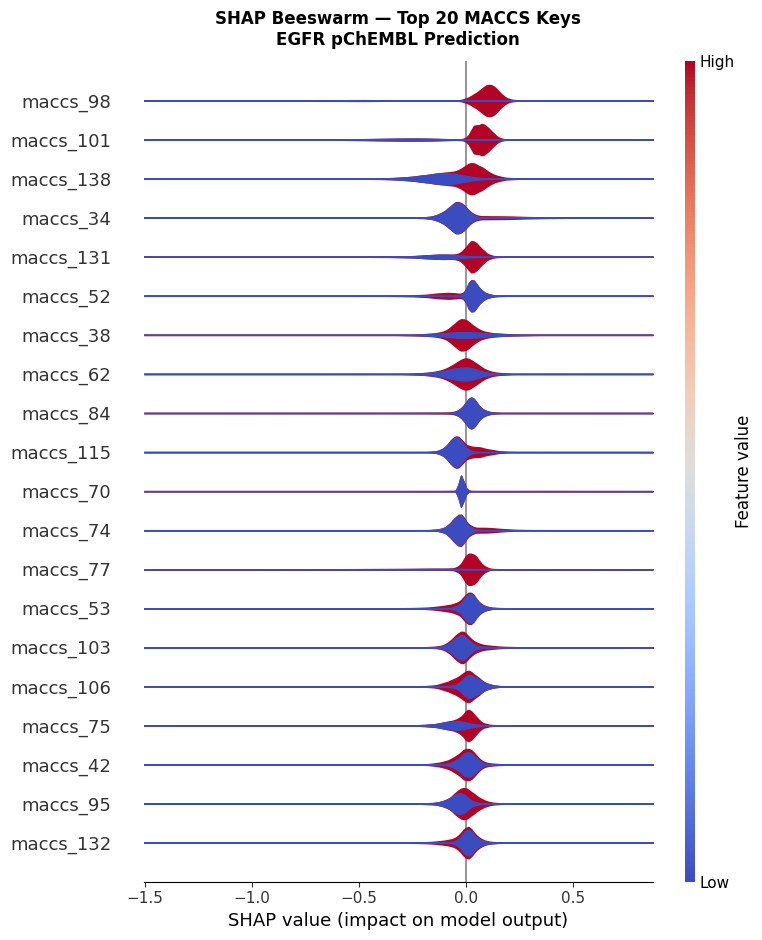

In [10]:
TOP_N = 20
top_features    = shap_importance.head(TOP_N)['feature'].tolist()
top_feature_idx = [maccs_cols.index(f) for f in top_features]

X_top    = X_maccs[:, top_feature_idx]
shap_top = shap_values[:, top_feature_idx]

# Direct beeswarm (summary_plot with kind='violin' or 'strip')
plt.figure(figsize=(11, 10))
shap.summary_plot(shap_top, X_top, feature_names=top_features, show=False, 
                  plot_type="layered_violin")  # 'dot' for beeswarm style
plt.title('SHAP Beeswarm — Top 20 MACCS Keys\nEGFR pChEMBL Prediction',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../figs/shap/part6_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Figure 2 — SHAP Bar Plot (Global Importance)

Simpler than beeswarm
mean |SHAP| per feature, with biological labels.

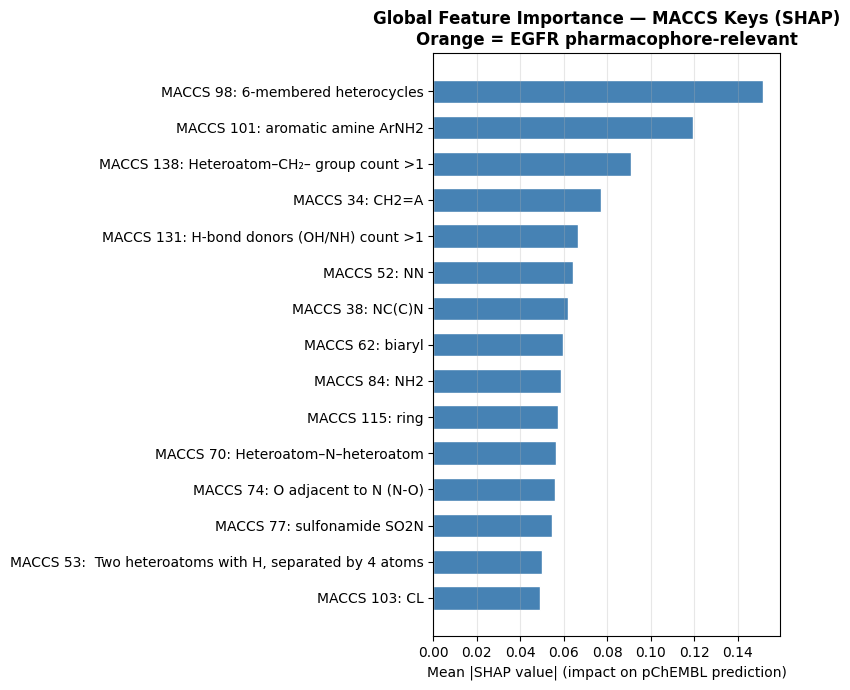

Saved part6_shap_bar.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

top15 = shap_importance.head(15).sort_values('mean_abs_shap')
labels = [f"MACCS {row.bit}: {row.description}" for _, row in top15.iterrows()]

bars = ax.barh(labels, top15['mean_abs_shap'],
               color='steelblue', edgecolor='white', height=0.65)

ax.set_xlabel('Mean |SHAP value| (impact on pChEMBL prediction)', fontsize=10)
ax.set_title('Global Feature Importance — MACCS Keys (SHAP)\n'
             'Orange = EGFR pharmacophore-relevant',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figs/shap/part6_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved part6_shap_bar.png')

---
## 6. Figure 3 — Molecular Similarity Maps

Colors each atom by how much its surrounding Morgan environment
contributes to the prediction.

We use Morgan fingerprint weights (not MACCS SHAP) for atom-level
coloring — this is the standard approach in RDKit's SimilarityMaps.

**Drugs used:**
- **Erlotinib** — 1st gen, reversible, quinazoline scaffold
- **Osimertinib** — 3rd gen, covalent, targets T790M resistance mutation
  (has the acrylamide warhead that MACCS bit 154 encodes)

In [ ]:
REFERENCE_DRUGS = {
    'Erlotinib'  : 'C#Cc1cccc(Nc2ncnc3cc(OCCO)c(OCCO)cc23)c1',
    'Gefitinib'  : 'COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1',
    'Osimertinib': 'CN1C=C(C2=CC=CC=C21)C3=NC(=NC=C3)NC4=C(C=C(C(=C4)NC(=O)C=C)N(C)CCN(C)C)OC',
    'Afatinib'   : 'C=CC(=O)N1CCC[C@@H]1c1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2c(OCC)c1',
}

from src.shap_utils import get_morgan_weights


# Load the ECFP6 model for atom-level coloring
with open('../models/best_model_part5.pkl', 'rb') as f:
    model_ecfp6 = pickle.load(f)

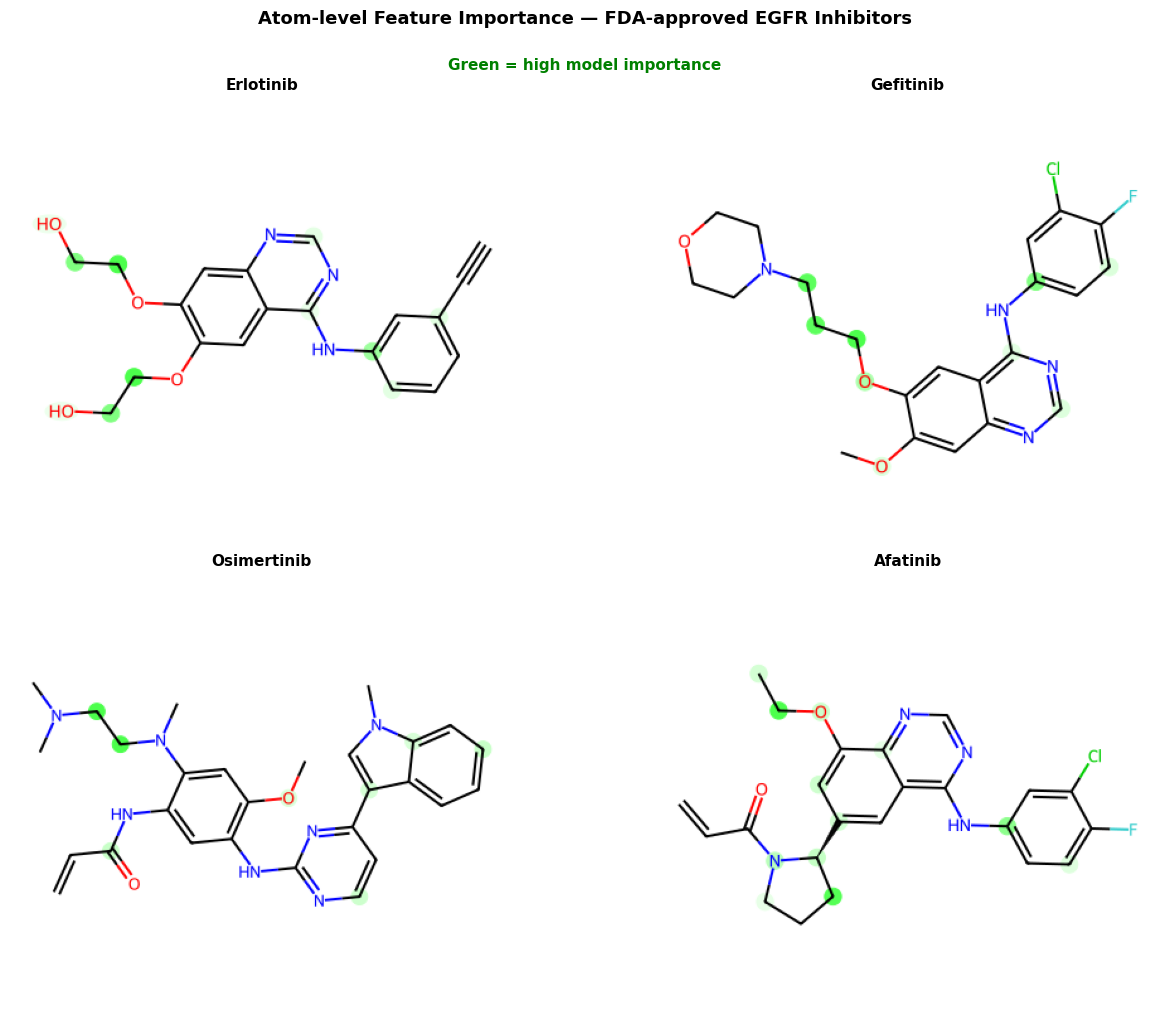

Saved part6_similarity_maps.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (drug_name, smiles) in zip(axes, REFERENCE_DRUGS.items()):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        ax.set_title(f"{drug_name} — invalid SMILES")
        ax.axis("off")
        continue

    atom_weights = get_morgan_weights(mol, model_ecfp6)

    drawer = rdMolDraw2D.MolDraw2DCairo(400, 350)
    draw_options = drawer.drawOptions()
    draw_options.addAtomIndices = False

    # Prepare weights array once
    n_atoms = mol.GetNumAtoms()
    weights = np.fromiter(
        (atom_weights.get(i, 0.0) for i in range(n_atoms)),
        dtype=float,
        count=n_atoms
    )

    max_w = weights.max()
    if max_w > 0:
        weights /= max_w

    highlight_atoms = []
    atom_colors = {}

    # Local bindings for speed
    highlight_threshold = 0.05

    for i, w in enumerate(weights):
        if w > highlight_threshold:
            c = 1.0 - w * 0.7
            atom_colors[i] = (c, 1.0, c)
            highlight_atoms.append(i)

    rdMolDraw2D.PrepareMolForDrawing(mol)
    drawer.DrawMolecule(
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_colors,
        highlightBonds=[]
    )
    drawer.FinishDrawing()

    img = PILImage.open(io.BytesIO(drawer.GetDrawingText()))
    ax.imshow(np.array(img))
    ax.set_title(f"{drug_name}",
                 fontweight="bold", fontsize=11)
    ax.axis("off")

plt.suptitle(
    "Atom-level Feature Importance — FDA-approved EGFR Inhibitors",
    fontweight="bold",
    fontsize=13,
    y=1.02  # slightly increased to avoid overlap with subplot titles
)

fig.text(0.5, 0.96, "Green = high model importance",
         fontsize=11, fontweight="bold", color="green", ha="center")

plt.tight_layout()
plt.savefig("../figs/shap/part6_similarity_maps.png",
            dpi=150,
            bbox_inches="tight")

plt.show()
print("Saved part6_similarity_maps.png")